In [ ]:
#Gender
#Exercise
#Weather Conditions

In [4]:
import pandas as pd

# ladda dataset
df = pd.read_csv("../data/exercise_dataset.csv")

df.head()

,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4
3,4,Exercise 5,127.183858,79.477008,82.984456,33,Male,39,170,33.729552,Sunny,10
4,5,Exercise 10,416.318374,89.960226,85.643174,29,Female,34,118,23.286113,Cloudy,3


In [5]:
pd.crosstab(df["Gender"], df["Exercise"])

Exercise,Exercise 1,Exercise 10,Exercise 2,Exercise 3,Exercise 4,Exercise 5,Exercise 6,Exercise 7,Exercise 8,Exercise 9
Gender,,,,,,,,,,
Female,217,212,170,206,191,206,179,188,203,192
Male,186,186,175,179,180,198,202,198,194,202


In [6]:
pd.crosstab(df["Gender"], df["Exercise"], normalize="index")

Exercise,Exercise 1,Exercise 10,Exercise 2,Exercise 3,Exercise 4,Exercise 5,Exercise 6,Exercise 7,Exercise 8,Exercise 9
Gender,,,,,,,,,,
Female,0.110489,0.107943,0.086558,0.104888,0.097251,0.104888,0.091141,0.095723,0.103360,0.097760
Male,0.097895,0.097895,0.092105,0.094211,0.094737,0.104211,0.106316,0.104211,0.102105,0.106316


In [9]:
!pip install prince

In [12]:
import prince

# skapa kontingenstabell
table = pd.crosstab(df["Gender"], df["Exercise"])

# skapa modell
ca = prince.CA(n_components=2)

# träna
ca = ca.fit(table)

# koordinater
row_coords = ca.row_coordinates(table)
col_coords = ca.column_coordinates(table)

In [17]:
print(row_coords.head())
print(row_coords.columns)

print(col_coords.head())
print(col_coords.columns)

               0
Gender          
Female -0.043566
Male    0.045034
RangeIndex(start=0, stop=1, step=1)
                    0
Exercise             
Exercise 1  -0.060368
Exercise 10 -0.048770
Exercise 2   0.031060
Exercise 3  -0.053574
Exercise 4  -0.013088
RangeIndex(start=0, stop=1, step=1)


In [19]:
table = pd.crosstab(df["Weather Conditions"], df["Exercise"])
table

Exercise,Exercise 1,Exercise 10,Exercise 2,Exercise 3,Exercise 4,Exercise 5,Exercise 6,Exercise 7,Exercise 8,Exercise 9
Weather Conditions,,,,,,,,,,
Cloudy,141,136,130,135,132,148,126,121,129,134
Rainy,141,136,108,131,120,133,127,147,125,127
Sunny,121,126,107,119,119,123,128,118,143,133


In [21]:
import prince

table = pd.crosstab(df["Weather Conditions"], df["Exercise"])

ca = prince.CA(n_components=2)
ca = ca.fit(table)

row_coords = ca.row_coordinates(table)
col_coords = ca.column_coordinates(table)

print(row_coords.shape)
print(col_coords.shape)
print(row_coords.head())
print(col_coords.head())

(3, 2)
(10, 2)
                           0         1
Weather Conditions                    
Cloudy             -0.013029  0.050154
Rainy               0.054194 -0.015799
Sunny              -0.042705 -0.037466
                    0         1
Exercise                       
Exercise 1   0.039185  0.020602
Exercise 10  0.013553 -0.003252
Exercise 2  -0.029487  0.062347
Exercise 3   0.016651  0.016845
Exercise 4  -0.019949  0.019161


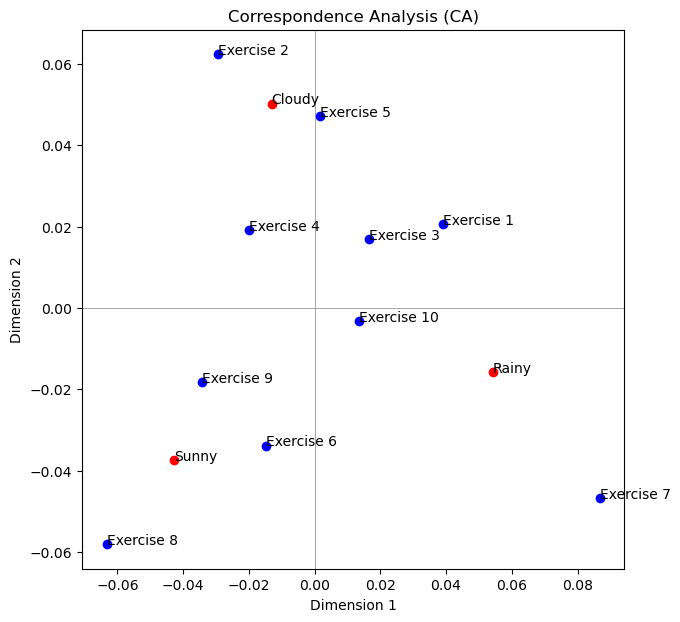

In [22]:
plt.figure(figsize=(7,7))

# plot rows (Gender)
plt.scatter(row_coords.iloc[:, 0], row_coords.iloc[:, 1], color="red")

for i, txt in enumerate(row_coords.index):
    plt.text(row_coords.iloc[i, 0], row_coords.iloc[i, 1], txt)

# plot columns (Exercise)
plt.scatter(col_coords.iloc[:, 0], col_coords.iloc[:, 1], color="blue")

for i, txt in enumerate(col_coords.index):
    plt.text(col_coords.iloc[i, 0], col_coords.iloc[i, 1], txt)

plt.title("Correspondence Analysis (CA)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.show()

In [23]:
print(table.shape)

(3, 10)


## Correspondence Analysis (CA)

This analysis explores the relationship between weather conditions and types of exercise.

Points that are close together indicate stronger associations, while points that are far apart indicate weaker relationships.

The results show that different weather conditions are associated with different exercise patterns.